## Setup

In [3]:
import os, sys
sys.path.insert(0, '..')           # ucvla root
sys.path.insert(0, '../../RDT2')  # for codec registration

from data.umi.codecs.imagecodecs_numcodecs import register_codecs
register_codecs()

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from zarr_loader import load_episodes
from trajectory import dba, compute_weights, global_norm_stats, make_traj

ZARR_DIR  = '../umi_data'
PROTO_NPZ = '../outputs/preference_viz/prototypes.npz'  # set None to recompute

numcodec 'imagecodecs_aec' already registered
numcodec 'imagecodecs_apng' already registered
numcodec 'imagecodecs_avif' already registered
numcodec 'imagecodecs_bitorder' already registered
numcodec 'imagecodecs_bitshuffle' already registered
numcodec 'imagecodecs_blosc' already registered
numcodec 'imagecodecs_blosc2' already registered
numcodec 'imagecodecs_brotli' already registered
numcodec 'imagecodecs_byteshuffle' already registered
numcodec 'imagecodecs_bz2' already registered
numcodec 'imagecodecs_cms' already registered
numcodec 'imagecodecs_deflate' already registered
numcodec 'imagecodecs_delta' already registered
numcodec 'imagecodecs_float24' already registered
numcodec 'imagecodecs_floatpred' already registered
numcodec 'imagecodecs_gif' already registered
numcodec 'imagecodecs_heif' already registered
numcodec 'imagecodecs_jetraw' already registered
numcodec 'imagecodecs_jpeg' already registered
numcodec 'imagecodecs_jpeg2k' already registered
numcodec 'imagecodecs_jpeg

## Load episodes

In [4]:
all_by_user = {}
for uid in range(3):
    all_by_user[uid] = load_episodes(f'{ZARR_DIR}/replay_buffer_u{uid}.zarr', load_rgb=True)
    lens = [len(ep['action']) for ep in all_by_user[uid]]
    print(f'u{uid}: {len(lens)} episodes, len=[{min(lens)},{max(lens)}] mean={np.mean(lens):.0f}')

all_flat = [ep for eps in all_by_user.values() for ep in eps]
action_mean, action_std = global_norm_stats(all_flat)

u0: 112 episodes, len=[166,338] mean=220
u1: 99 episodes, len=[230,417] mean=306
u2: 118 episodes, len=[157,335] mean=232


## DBA prototypes — compute or load cache

In [5]:
prototypes = {}
if PROTO_NPZ and os.path.exists(PROTO_NPZ):
    npz = np.load(PROTO_NPZ)
    for uid in range(3):
        prototypes[uid] = npz[f'u{uid}']
        print(f'  u{uid}: {prototypes[uid].shape}')
    print('Loaded from cache.')
else:
    print('Computing DBA prototypes (a few minutes)...')
    for uid in range(3):
        other_trajs = [
            make_traj(ep, action_mean, action_std)
            for u, eps in all_by_user.items() if u != uid
            for ep in eps
        ]
        print(f'u{uid}: DBA over {len(other_trajs)} episodes...')
        prototypes[uid] = dba(other_trajs, n_iters=10)
    os.makedirs('../outputs/preference_viz', exist_ok=True)
    np.savez(PROTO_NPZ, **{f'u{uid}': prototypes[uid] for uid in range(3)})
    print(f'Saved → {PROTO_NPZ}')

Computing DBA prototypes (a few minutes)...
u0: DBA over 217 episodes...
  DBA iter 1/10
  DBA iter 2/10
  DBA iter 3/10
  DBA iter 4/10
  DBA iter 5/10
  DBA iter 6/10
  DBA iter 7/10
  DBA iter 8/10
  DBA iter 9/10
  DBA iter 10/10
u1: DBA over 230 episodes...
  DBA iter 1/10
  DBA iter 2/10
  DBA iter 3/10
  DBA iter 4/10
  DBA iter 5/10
  DBA iter 6/10
  DBA iter 7/10
  DBA iter 8/10
  DBA iter 9/10
  DBA iter 10/10
u2: DBA over 211 episodes...
  DBA iter 1/10
  DBA iter 2/10
  DBA iter 3/10
  DBA iter 4/10
  DBA iter 5/10
  DBA iter 6/10
  DBA iter 7/10
  DBA iter 8/10
  DBA iter 9/10
  DBA iter 10/10
Saved → ../outputs/preference_viz/prototypes.npz


## Pick a user + episode

In [14]:
USER_ID = 2   # ← change
EP_IDX  = 40   # ← change

ep      = all_by_user[USER_ID][EP_IDX]
traj    = make_traj(ep, action_mean, action_std)
weights = compute_weights(traj, prototypes[USER_ID])

print(f'Length : {len(traj)} frames')
print(f'Weights: min={weights.min():.3f}  mean={weights.mean():.3f}  max={weights.max():.3f}')
print(f'Preference frames (w>2): {(weights > 2.0).sum()}')

Length : 257 frames
Weights: min=0.082  mean=1.000  max=1.858
Preference frames (w>2): 0


## Weight curve

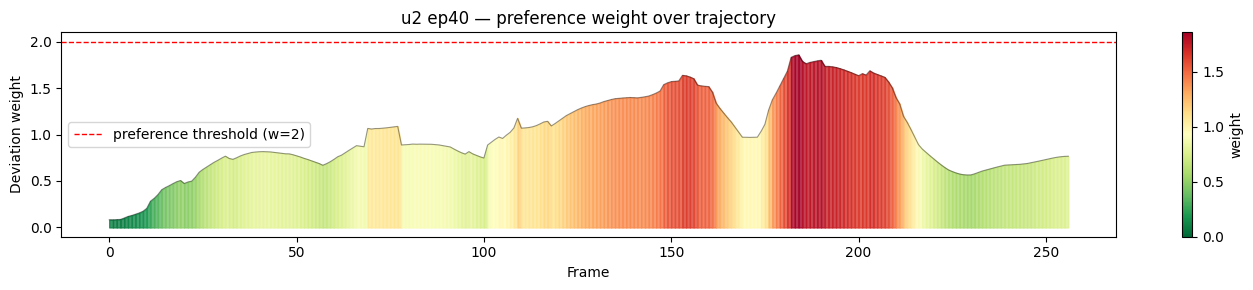

In [15]:
cmap = plt.cm.RdYlGn_r
norm = Normalize(vmin=0, vmax=weights.max())

fig, ax = plt.subplots(figsize=(14, 3))
for t in range(len(weights) - 1):
    ax.fill_between([t, t+1], [weights[t], weights[t+1]],
                    color=cmap(norm(weights[t])), alpha=0.8)
ax.plot(weights, color='black', lw=0.8, alpha=0.4)
ax.axhline(2.0, color='red', lw=1, linestyle='--', label='preference threshold (w=2)')
ax.set_xlabel('Frame'); ax.set_ylabel('Deviation weight')
ax.set_title(f'u{USER_ID} ep{EP_IDX} — preference weight over trajectory')
ax.legend()
plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='weight')
plt.tight_layout(); plt.show()

## Frame strip

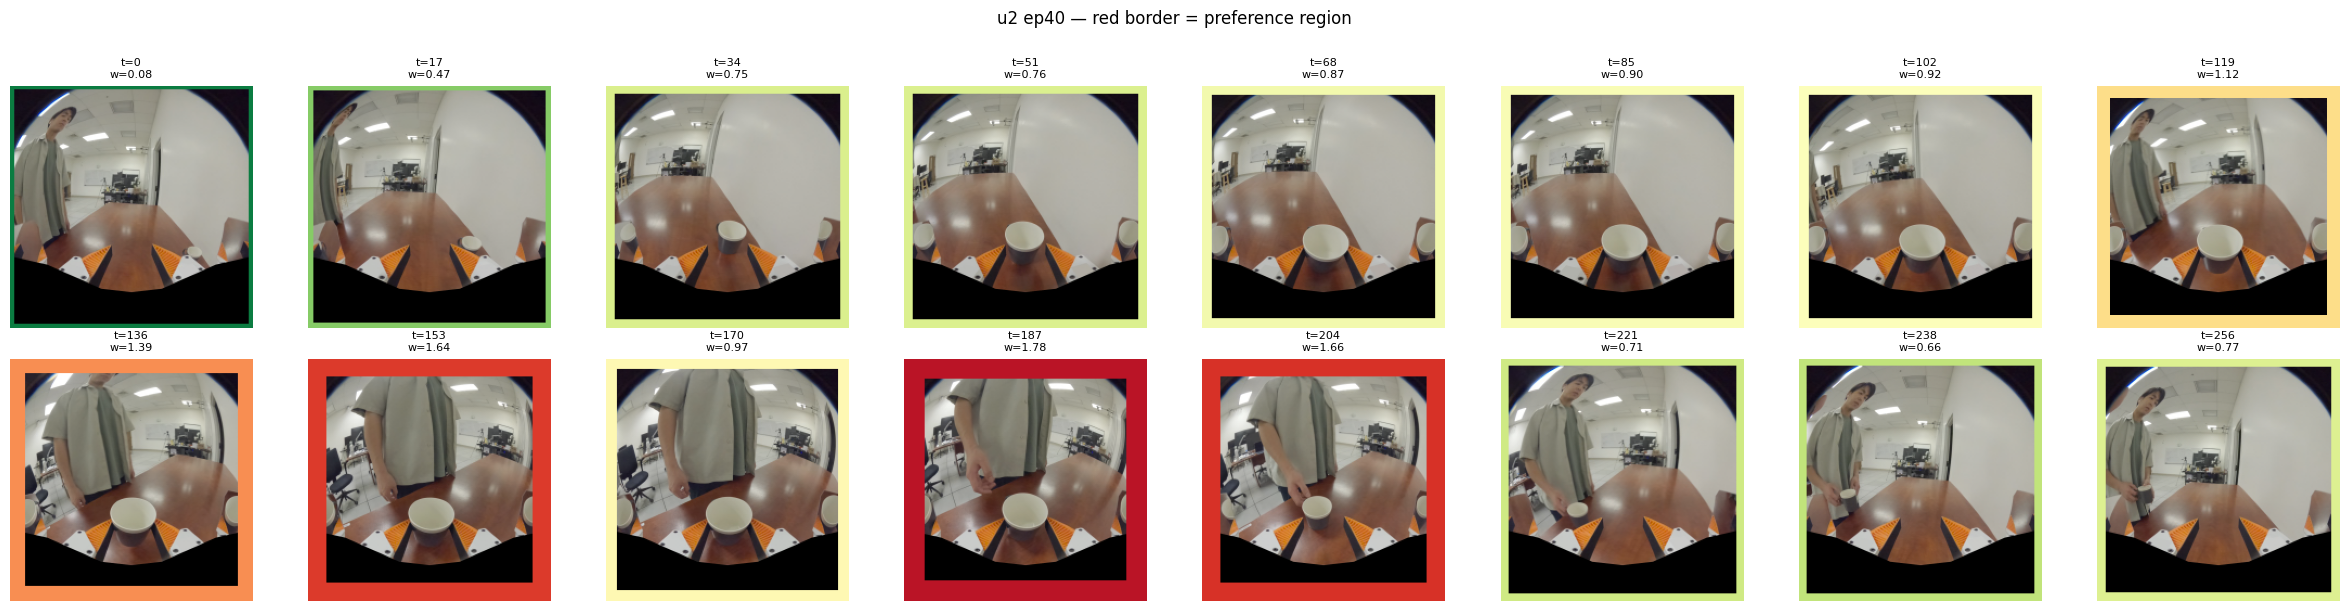

In [16]:
N_FRAMES = 16
indices  = np.linspace(0, len(ep['rgb']) - 1, N_FRAMES, dtype=int)

fig, axes = plt.subplots(2, N_FRAMES // 2, figsize=(N_FRAMES * 1.5, 6))
for ax, t in zip(axes.flatten(), indices):
    w      = weights[t]
    w_norm = float(np.clip(w / weights.max(), 0, 1))
    color  = cmap(w_norm)
    border = max(4, int(w_norm * 20))
    img    = ep['rgb'][t].copy()
    c = (np.array(color[:3]) * 255).astype(np.uint8)
    img[:border] = c;  img[-border:] = c
    img[:, :border] = c;  img[:, -border:] = c
    ax.imshow(img)
    ax.set_title(f't={t}\nw={w:.2f}', fontsize=8,
                 color='red' if w > 2.0 else 'black',
                 fontweight='bold' if w > 2.0 else 'normal')
    ax.axis('off')

plt.suptitle(f'u{USER_ID} ep{EP_IDX} — red border = preference region', y=1.01)
plt.tight_layout(); plt.show()

## All 3 users compared

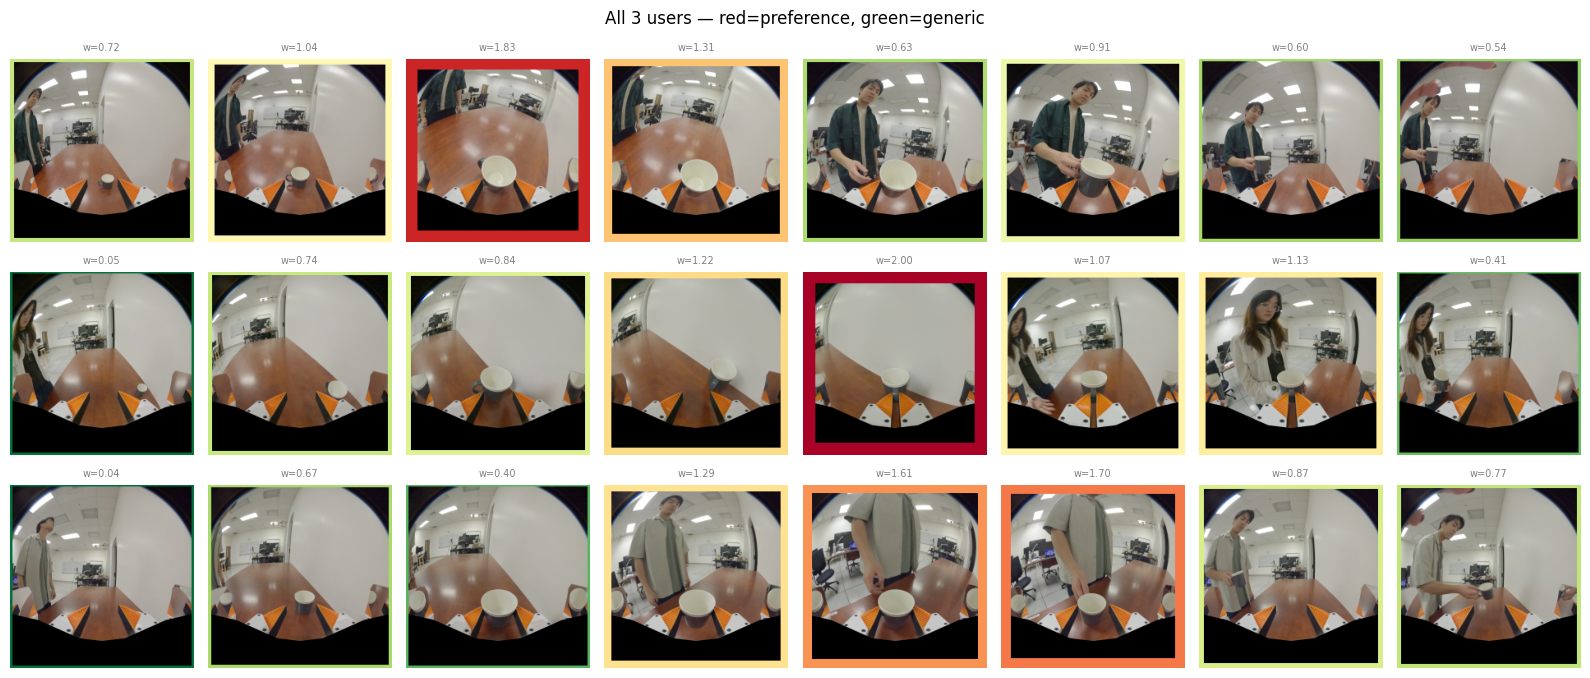

In [17]:
EP_IDX_CMP   = 0   # ← change
N_FRAMES_CMP = 8

fig, axes = plt.subplots(3, N_FRAMES_CMP, figsize=(N_FRAMES_CMP * 2, 7))
for row, uid in enumerate([0, 1, 2]):
    ep_cmp  = all_by_user[uid][EP_IDX_CMP]
    w_cmp   = compute_weights(
        make_traj(ep_cmp, action_mean, action_std), prototypes[uid]
    )
    w_max   = w_cmp.max() or 1.0
    idxs    = np.linspace(0, len(ep_cmp['rgb']) - 1, N_FRAMES_CMP, dtype=int)
    for col, t in enumerate(idxs):
        ax     = axes[row, col]
        w      = w_cmp[t]
        w_norm = float(np.clip(w / w_max, 0, 1))
        color  = cmap(w_norm)
        border = max(3, int(w_norm * 16))
        img    = ep_cmp['rgb'][t].copy()
        c = (np.array(color[:3]) * 255).astype(np.uint8)
        img[:border] = c;  img[-border:] = c
        img[:, :border] = c;  img[:, -border:] = c
        ax.imshow(img)
        ax.set_title(f'w={w:.2f}', fontsize=7,
                     color='red' if w > 2.0 else 'gray')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f'user {uid}', fontsize=10)

plt.suptitle('All 3 users — red=preference, green=generic')
plt.tight_layout(); plt.show()